In [17]:
%pip install --upgrade pip -q
%pip install neo4j -q
%pip install python-dotenv -q
%pip install py2neo networkx -q

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import IPython

# restart python kernel
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 

# Preamble

In [4]:
from datetime import datetime
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from dotenv import load_dotenv

from neo4j import GraphDatabase

# visualization of the graph here
import networkx as nx
from py2neo import Graph
from IPython.display import HTML, display
import json

In [5]:
start_date = datetime(2025, 7, 11)

# Loading aggregated data

Run the download_data.sh script first.  

## RQ1

In [59]:
aggr_rua_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=rua_addresses/").rename(columns={"sum(count)": "count"})
aggr_ruf_pdf = pd.read_parquet("../data/oi-warehouse/aggregation/what=ruf_addresses/").rename(columns={"sum(count)": "count"})

aggr_rua_pdf["rua_apex_domain"] = aggr_rua_pdf['rua_apex_domain'] = aggr_rua_pdf['rua_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})
aggr_ruf_pdf["ruf_apex_domain"] = aggr_ruf_pdf['ruf_apex_domain'] = aggr_ruf_pdf['ruf_apex_domain'].replace({None: 'Invalid', np.nan: 'Invalid'})

aggr_rua_ruf_pdf = pd.concat([
    aggr_rua_pdf.rename(columns={"rua_apex_domain": "rua_ruf_apex_domain"}), 
    aggr_ruf_pdf.rename(columns={"ruf_apex_domain": "rua_ruf_apex_domain"})
], ignore_index=True).drop(columns=["source", "year", "month", "day"]
).groupby("rua_ruf_apex_domain", as_index=False).agg(count=("count", "sum")
).sort_values("count", ascending=False)
aggr_rua_ruf_pdf["percent"] = aggr_rua_ruf_pdf["count"] / aggr_rua_ruf_pdf["count"].sum() * 100

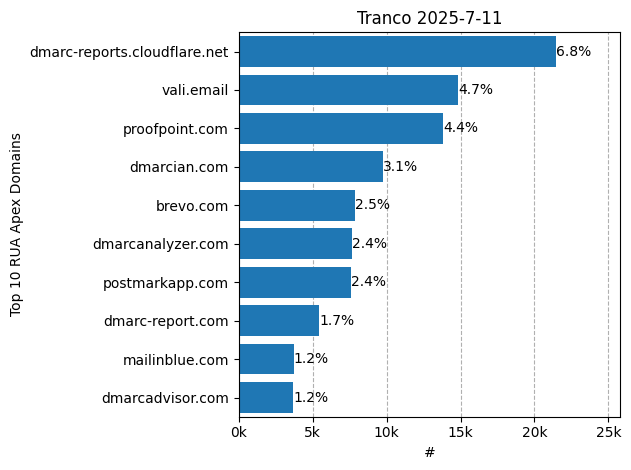

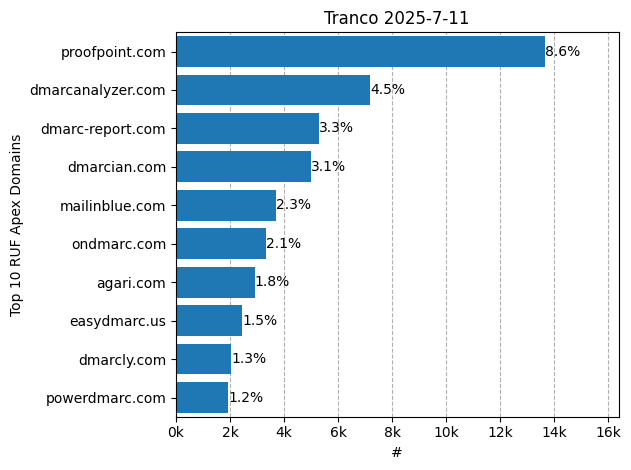

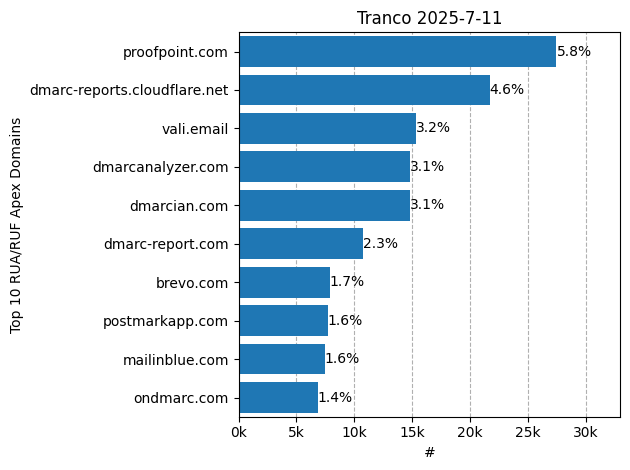

In [60]:
def _plot_dmarc_ruaruf_tag(top_n, domain_tag, ylabel, start_date):
    plt.figure()

    _ = plt.barh(top_n[domain_tag], top_n["count"])
    for i, (count, percent) in enumerate(zip(top_n["count"], top_n["percent"])):
        plt.text(count + 1, i, f'{percent:.1f}%', va='center', ha='left')

    plt.title(f"Tranco {start_date.year}-{start_date.month}-{start_date.day}")
    plt.xlabel("#")
    plt.ylabel(ylabel)
    plt.xlim(0, top_n["count"].max() * 1.2)
    thousands = ticker.FuncFormatter(lambda x, pos: f"{int(x/1000)}k")
    plt.gca().xaxis.set_major_formatter(thousands)
    plt.gca().set_axisbelow(True)
    plt.gca().xaxis.grid(True, linestyle='--')

    num_categories = len(top_n)
    plt.ylim(-.5, num_categories - .5)  # Minimal padding
    plt.gca().invert_yaxis()  # To show highest values at top

    plt.tight_layout()
    plt.savefig(f"figures/{domain_tag}_proportion.pdf", bbox_inches='tight')
    plt.show()


_plot_dmarc_ruaruf_tag(aggr_rua_pdf.head(10), "rua_apex_domain", "Top 10 RUA Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_ruf_pdf.head(10), "ruf_apex_domain", "Top 10 RUF Apex Domains", start_date)
_plot_dmarc_ruaruf_tag(aggr_rua_ruf_pdf.head(10), "rua_ruf_apex_domain", "Top 10 RUA/RUF Apex Domains", start_date)

top 10 are all organisations (no individuals/admins)   
dmarc-report.com - doesn't exist  
postmarkapp.com - email delivery company  
cloudflare - cdn with email sec service  
the rest are email security companies.  

related work: proofpoint.com, reportdmarc.nl, mailingblue.com, agari.com, dmarcanalyzer.com, 163.com, dmarcian.com, dmarc-report.com, amazon.com, cloudflare.net, vali.email, gmail.com, secureserver.net, cisco.com, dmarcadvisor.com, domeneshop.no, postmarkapp.com, ondmarc.com, barracudanetworks.com, microhost.pl  

#### Neo4j connection

In [6]:
class Neo4jConnection:
    def __init__(self, uri, user, password):
        self.uri = uri
        self.user = user
        self.password = password
        self.driver = None

    def __enter__(self):
        """Enter the context manager - establish connection"""
        self.driver = GraphDatabase.driver(self.uri, auth=(self.user, self.password))
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        """Exit the context manager - close connection"""
        if self.driver:
            self.driver.close()

    def test_connection(self):
        with self.driver.session() as session:
            result = session.run("RETURN 'Connection successful' as message")
            print(result.single()["message"])

    def query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return [record.data() for record in result]

    def query_to_df(self, query, parameters=None):
        results = self.query(query, parameters)
        return pd.DataFrame(results)

    def write_query(self, query, parameters=None):
        if not self.driver:
            raise RuntimeError("Connection not established. Use within 'with' statement.")

        with self.driver.session() as session:
            result = session.run(query, parameters)
            return result.consume().counters

load_dotenv()
NEO4J_PASSWD = os.getenv('NEO4J_PASSWD')
if not NEO4J_PASSWD:
    raise ValueError("NEO4J_PASSWD not found in environment variables")

URI = "bolt://localhost:7687"
AUTH = ("neo4j", NEO4J_PASSWD)

Warning! RUN THIS ONLY ONCE TO SET UP THE DATABASE

In [64]:
with Neo4jConnection(URI, *AUTH) as conn:
    conn.test_connection()
    conn.write_query("CREATE INDEX vertices_id_index IF NOT EXISTS FOR (n:Vertices) ON (n.id)")
    conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///vertices.csv" AS row
            CREATE (:Vertices {id: row.id})
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    result = conn.query("MATCH (n:Vertices) RETURN count(n) as total_vertices")
    print(f"Total vertices in database: {result[0]['total_vertices']}")

    result_rua = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///rua_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUA]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUA edges created: {result_rua.relationships_created}")

    result_ruf = conn.write_query("""
        CALL () {
            LOAD CSV WITH HEADERS FROM "file:///ruf_edges.csv" AS row
            MATCH (source:Vertices {id: row.src})
            MATCH (destination:Vertices {id: row.dst})
            MERGE (source)-[:RUF]->(destination)
        } IN TRANSACTIONS OF 5000 ROWS
    """)
    print(f"RUF edges created: {result_ruf.relationships_created}")

Connection successful
Total vertices in database: 439947
RUA edges created: 315274
RUF edges created: 158219


In [ ]:
# cleaning up the database
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    conn.query("""
        CALL gds.graph.drop('DMARC')
    """)

    conn.query("""
        MATCH ()-[r]-()
        DELETE r;
    """)

    conn.query("""
        MATCH (n)
        DELETE n;
    """)

    result = conn.query("""
        MATCH (n)
        RETURN count(n) AS node_count
    """)
    print(f"Total nodes in database after cleanup: {result[0]['node_count']}")
    result = conn.query("""
        MATCH ()-[r]-()
        RETURN count(r) AS relationship_count
    """)
    print(f"Total relationships in database after cleanup: {result[0]['relationship_count']}")

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.FeatureDeprecationWarning} {category: DEPRECATION} {title: This feature is deprecated and will be removed in future versions.} {description: The procedure has a deprecated field. ('schema' returned by 'gds.graph.drop' is deprecated.)} {position: line: 2, column: 9, offset: 9} for query: "\n        CALL gds.graph.drop('DMARC')\n    "


Best visualized at cypher using:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
RETURN n, r, m  
LIMIT 50;  


Visualize individual nodes:  

MATCH (n:Vertices)-[r]->(m:Vertices)  
WHERE n.id = "bibleminute.co"  
RETURN n, r, m  

##### Local visualization -- not good

In [ ]:
def visualize_with_existing_connection(conn, query, limit=50):
    # Get data using your existing connection
    data = conn.query(f"{query} LIMIT {limit}")

    # Create NetworkX graph
    G = nx.DiGraph()  # Directed graph for RUA/RUF relationships

    # Process the data
    for record in data:
        if 'source' in record and 'target' in record:
            G.add_edge(record['source'], record['target'], 
                      rel_type=record.get('relationship', 'CONNECTED'))

    # Visualization
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)

    # Different colors for different relationship types
    edge_colors = []
    for u, v, d in G.edges(data=True):
        if d.get('rel_type') == 'RUA':
            edge_colors.append('red')
        elif d.get('rel_type') == 'RUF':
            edge_colors.append('blue')
        else:
            edge_colors.append('gray')

    # Draw the graph
    nx.draw_networkx_nodes(G, pos, node_color='lightgreen', 
                          node_size=300, alpha=0.8)
    nx.draw_networkx_edges(G, pos, edge_color=edge_colors, 
                          arrows=True, arrowsize=20, alpha=0.6)
    nx.draw_networkx_labels(G, pos, font_size=6, font_weight='bold')

    plt.title(f"Graph Visualization ({len(G.nodes())} nodes, {len(G.edges())} edges)")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # Print stats
    print(f"Nodes: {len(G.nodes())}")
    print(f"Edges: {len(G.edges())}")

    return G

# horrible visualization; no other better python choice... use cypher which is better
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # Query that returns source, target, relationship
    query = """
        MATCH (n:Vertices)-[r]->(m:Vertices)
        RETURN n.id as source, m.id as target, type(r) as relationship
    """

    graph = visualize_with_existing_connection(conn, query, limit=50)

#### Connected Components algorithm

In [ ]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    current_graphs = conn.query("""
        CALL gds.graph.list()
        YIELD graphName, nodeCount, relationshipCount
        RETURN graphName, nodeCount, relationshipCount
        ORDER BY graphName
    """)

    if current_graphs:
        print("Current graph projections:")
        for graph in current_graphs:
            print(f"  {graph['graphName']}: {graph['nodeCount']} nodes, {graph['relationshipCount']} relationships")
        if False: # delete graph!
            for graph in current_graphs:
                conn.write_query(f"CALL gds.graph.drop({graph['graphName']}) YIELD graphName;")
                print(f"Dropped existing graph projection {graph['graphName']}.")
    else:
        conn.write_query("""
            CALL gds.graph.project(
                'DMARC',
                'Vertices',
                ['RUA', 'RUF']
            )
        """)

#  DMARC: 439947 nodes, 473493 relationships


Current graph projections:
  DMARC: 439947 nodes, 473493 relationships


In [67]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        RETURN  componentId, 
                collect(gds.util.asNode(nodeId).id) AS node_ids,
                size(collect(gds.util.asNode(nodeId).id)) AS component_size
        ORDER BY size(node_ids) DESC
        LIMIT 10;
    """)
    display(result_pdf)

,componentId,node_ids,component_size
0,0,"[kimballmidwest.com, cheval-shop.com, milleniu...",147177
1,1966,"[army-surplus.cz, defendia.cz, brainmarket.sk,...",150
2,1849,"[bmw.hu, alphabet.pl, mini.es, mini.my, mini.c...",109
3,2551,"[ta.no, bygdeposten.no, dt.no, laagendalsposte...",91
4,6212,"[thepoliticalglobe.com, republicanpress.org, t...",89
5,3628,"[housetrip.com, flipkey.com, tripadvisor.co.kr...",83
6,1995,"[actu-femmes-senior.fr, infocronacanera.it, vo...",78
7,4031,"[inwentury.pl, griggio.pl, brd.edu.pl, bestspe...",67
8,1962,"[netdoktor.se, ljusdalsposten.se, skovdenyhete...",64
9,3236,"[blpprofessional.com, bloomberg.com.br, bloomb...",60


In [68]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    clusters_pdf = conn.query_to_df("""
        CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})
        YIELD nodeId, componentId
        WITH componentId, collect(gds.util.asNode(nodeId).id) AS node_ids
        WHERE size(node_ids) > 1  // Only multi-node components

        // For each component, get top n most connected nodes
        UNWIND node_ids AS node_id
        MATCH (target:Vertices {id: node_id})
        OPTIONAL MATCH (source:Vertices)-[r:RUA|RUF]->(target)
        WHERE source.id IN node_ids
        WITH componentId, node_ids, target.id AS vertex_id, count(r) AS incoming_count
        ORDER BY componentId, incoming_count DESC

        // Get top 5 nodes per component
        //WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count})[0..5] AS top_nodes
        WITH componentId, node_ids, collect({vertex: vertex_id, incoming: incoming_count}) AS top_nodes

        RETURN componentId,
            size(node_ids) AS component_size,
            top_nodes
        ORDER BY component_size DESC
        //LIMIT 10;
    """)
    display(clusters_pdf)

,componentId,component_size,top_nodes
0,0,147177,"[{'incoming': 27462, 'vertex': 'proofpoint.com..."
1,1966,150,"[{'incoming': 300, 'vertex': 'leadhub.co'}, {'..."
2,1849,109,"[{'incoming': 216, 'vertex': 'bmwgroup.com'}, ..."
3,2551,91,"[{'incoming': 91, 'vertex': 'amedia.no'}, {'in..."
4,6212,89,"[{'incoming': 88, 'vertex': 'esps5.com'}, {'in..."
...,...,...,...
17405,418485,2,"[{'incoming': 1, 'vertex': 'activesphere.eu'},..."
17406,420829,2,"[{'incoming': 2, 'vertex': 'hightechcampus.com..."
17407,432229,2,"[{'incoming': 1, 'vertex': 'dracnet.com'}, {'i..."
17408,435314,2,"[{'incoming': 1, 'vertex': 'DULICHVIET.COM.VN'..."


In [ ]:
# row 6 is tripadvisor
display(clusters_pdf["top_nodes"].iloc[5])

[{'incoming': 143, 'vertex': 'tripadvisor.com'},
 {'incoming': 0, 'vertex': 'housetrip.com'},
 {'incoming': 0, 'vertex': 'flipkey.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.co.kr'},
 {'incoming': 0, 'vertex': 'tripadvisor.ca'},
 {'incoming': 0, 'vertex': 'cruisecritic.com.au'},
 {'incoming': 0, 'vertex': 'tripadvisor.cn'},
 {'incoming': 0, 'vertex': 'viatorsystems.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.cl'},
 {'incoming': 0, 'vertex': 'cruisecritic.co.uk'},
 {'incoming': 0, 'vertex': 'thefork.it'},
 {'incoming': 0, 'vertex': 'tripadvisor.jp'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.eg'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.vn'},
 {'incoming': 0, 'vertex': 'tripadvisor.at'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.tr'},
 {'incoming': 0, 'vertex': 'thefork.nl'},
 {'incoming': 0, 'vertex': 'tripadvisor.de'},
 {'incoming': 0, 'vertex': 'tripadvisorsupport.com'},
 {'incoming': 0, 'vertex': 'tripadvisor.com.sg'},
 {'incoming': 0, 'vertex': 'tripadvisor.sk'},
 {'i

In [82]:
display(clusters_pdf["top_nodes"].iloc[2])

[{'incoming': 216, 'vertex': 'bmwgroup.com'},
 {'incoming': 0, 'vertex': 'bmw.hu'},
 {'incoming': 0, 'vertex': 'alphabet.pl'},
 {'incoming': 0, 'vertex': 'mini.es'},
 {'incoming': 0, 'vertex': 'mini.my'},
 {'incoming': 0, 'vertex': 'mini.co.kr'},
 {'incoming': 0, 'vertex': 'bmwlat.com'},
 {'incoming': 0, 'vertex': 'mini.dk'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.fr'},
 {'incoming': 0, 'vertex': 'bmw.be'},
 {'incoming': 0, 'vertex': 'mini.de'},
 {'incoming': 0, 'vertex': 'bmw.lu'},
 {'incoming': 0, 'vertex': 'bmw-welt.com'},
 {'incoming': 0, 'vertex': 'bmwgroupfs.com'},
 {'incoming': 0, 'vertex': 'bmw.no'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.es'},
 {'incoming': 0, 'vertex': 'bmw.in'},
 {'incoming': 0, 'vertex': 'mini.no'},
 {'incoming': 0, 'vertex': 'bmw.ca'},
 {'incoming': 0, 'vertex': 'bmw-motorrad.de'},
 {'incoming': 0, 'vertex': 'bmw.ch'},
 {'incoming': 0, 'vertex': 'mini.com'},
 {'incoming': 0, 'vertex': 'mini.in'},
 {'incoming': 0, 'vertex': 'bmwgroupdesignworks.com'},
 

Visualization of specific components

// First, get the node IDs for component 2  
CALL gds.wcc.stream('DMARC', {relationshipTypes: ['RUA', 'RUF']})  
YIELD nodeId, componentId  
WHERE componentId = 2  
WITH collect(gds.util.asNode(nodeId).id) AS component_nodes  

// Then visualize those nodes and their relationships  
MATCH (n:Vertices)  
WHERE n.id IN component_nodes  
MATCH (n)-[r:RUA|RUF]-(m:Vertices)  
WHERE m.id IN component_nodes  
RETURN n, r, m;  

What are the small clusters?  
Business relationships: subsidiaries sending dmarc report to their holding's mailbox.

If you own multiple domains, it makes sense that all rua and ruf reports are sent to the IT security mailbox, either the holding company, the regional domain or to a 3rd party processor. For instance, regional tripadvisor such as tripadvisor.be send reports to its main region tripadvisor.com. Also, housetrip.com seems a subsidiary of tripadvisor, which also send dmarc reports to tripadvisor.com. The holding company doesn't use any specialized mail security company, and hence, handles the reports in-house.

Although in this example the companies are under the group, they may be in different countries and hence, different data jurisdictions apply.

Can we distinguish subsidiaries and holdings automatically? maybe only using a web crawler...

Are the small clusters sending the report to the same data protection law?

#### Degree Centrality algorithm

"The degree centrality measures the number of incoming or outgoing (or both) relationships from a node, which can be defined by the orientation of a relationship projection. If a projection contains directed relationships, only outgoing relationships of a node are counted (the out-degree)." -- https://neo4j.com/docs/graph-data-science/current/algorithms/degree-centrality/  


In [74]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    # this is calculating the outdegree centrality, ie the top 10 domains that send rua/ruf reports to most distinct domains
    print("Calculating degree centrality using out-degree...")
    outdegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC')
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_outgoing_links
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 10;
    """)
    display(outdegree_pdf)

    print("Calculating degree centrality using in-degree...")
    indegree_pdf = conn.query_to_df("""
        CALL gds.degree.stream('DMARC', { orientation: 'REVERSE' })
        YIELD nodeId, score
        RETURN gds.util.asNode(nodeId).id AS domains, score AS nr_incoming_links
        ORDER BY nr_incoming_links DESC, domains DESC
        LIMIT 10;
    """)
    display(indegree_pdf)

Calculating degree centrality using out-degree...


,domains,nr_outgoing_links
0,bibleminute.co,9.0
1,baymack.com,9.0
2,wespire.com,8.0
3,prodpad.com,8.0
4,paypams.com,8.0
5,mailgun.com,8.0
6,legalvision.com.au,8.0
7,ecareer.ne.jp,8.0
8,corendonairlines.com,8.0
9,stocktradersdaily.com,7.0


Calculating degree centrality using in-degree...


,domains,nr_incoming_links
0,proofpoint.com,27462.0
1,dmarc-reports.cloudflare.net,21679.0
2,vali.email,15332.0
3,dmarcanalyzer.com,14835.0
4,dmarcian.com,14743.0
5,dmarc-report.com,10707.0
6,brevo.com,7886.0
7,postmarkapp.com,7685.0
8,mailinblue.com,7436.0
9,ondmarc.com,6833.0


In [80]:
def add_external_domains_to_pdf(row, src_column, dst_column):
    """Add a column to the DataFrame indicating if the outgoing links are to external domains."""
    src_domain = row[src_column]
    dst_domains = set(row[dst_column])
    row['external_domains'] = []
    for dst_domain in dst_domains:
        # Check if the destination domain is external
        if not dst_domain.endswith(src_domain):
            row['external_domains'] = row.get('external_domains', []) + [dst_domain]

    row['nr_external_domains'] = len(row['external_domains'])
    return row


with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    domains_outdegree_pdf = conn.query_to_df("""
        MATCH (n:Vertices)
        OPTIONAL MATCH (n)-[:RUA|RUF]->(connected)
        WITH n, collect(connected.id) AS outgoing_link_ids, count(connected) AS nr_outgoing_links
        RETURN n.id AS domains, nr_outgoing_links, outgoing_link_ids
        ORDER BY nr_outgoing_links DESC, domains DESC
        LIMIT 200
    """)
    # display(domains_outdegree_pdf)

domains_outdegree_pdf = domains_outdegree_pdf.apply(add_external_domains_to_pdf, axis=1, args=('domains', 'outgoing_link_ids'))
display(domains_outdegree_pdf)

,domains,nr_outgoing_links,outgoing_link_ids,external_domains,nr_external_domains
0,bibleminute.co,9,"[250ok.net, radiantdigital.com, dmarcian.com, ...","[dmarcian.com, 250ok.net, radiantdigital.com, ...",4
1,baymack.com,9,"[dmarcian.com, ondmarc.com, mailgun.org, easyd...","[dmarcian.com, easydmarc.asia, dmarc-reports.c...",6
2,wespire.com,8,"[dmarcinput.com, easydmarc.us, uriports.com, g...","[glockapps.com, easydmarc.us, dmarcinput.com, ...",4
3,prodpad.com,8,"[mailgun.org, ondmarc.com, prodpad.com, report...","[mailgun.org, ondmarc.com, report-uri.com]",3
4,paypams.com,8,"[dmarc-report.com, ondmarc.com, dmarcian.com, ...","[dmarcian.com, dmarc-reports.cloudflare.net, p...",5
...,...,...,...,...,...
195,infraspeak.com,6,"[infraspeak.com, easydmarc.eu, dmarcian.com, d...","[dmarcian.com, easydmarc.eu]",2
196,infinx.com,6,"[dmarcinput.com, infinx.com, infinx.com, trend...","[dmarcinput.com, trendmicro.com, dmarc-report....",3
197,infinum.com,6,"[mailhardener.com, uriports.com, infinum.com, ...","[mailhardener.com, uriports.com]",2
198,ify.ch,6,"[dmarcly.com, easydmarc.us, ify.ch, easydmarc....","[easydmarc.us, dmarcly.com]",2


In [79]:
print(
    domains_outdegree_pdf['domains'].iloc[0], domains_outdegree_pdf['external_domains'].iloc[0],
    '\n',
    domains_outdegree_pdf['domains'].iloc[1], domains_outdegree_pdf['external_domains'].iloc[1],
    '\n',
    domains_outdegree_pdf['domains'].iloc[2], domains_outdegree_pdf['external_domains'].iloc[2],
    '\n',
    domains_outdegree_pdf['domains'].iloc[99], domains_outdegree_pdf['external_domains'].iloc[99]
)

bibleminute.co ['dmarcian.com', '250ok.net', 'radiantdigital.com', 'dmarc-report.com'] 
 baymack.com ['dmarcian.com', 'easydmarc.asia', 'dmarc-reports.cloudflare.net', 'mailgun.org', 'ondmarc.com', 'dmarc-report.com'] 
 wespire.com ['glockapps.com', 'easydmarc.us', 'dmarcinput.com', 'uriports.com'] 
 ripc.gov.sa ['dmarc-report.com', 'dmarc.gov.sa']


Why one domain would send the report to multiple mailboxes?  
To send copies of reports to different parties. For example, you can send to a mailbox of your own domain, to a mailbox of an external domain, e.g., the holder company (in case the source domain is a subsidiary company), and send to a company specialized in processing DMARC reports such as DMARCian. One example is bibleminute.co, which is a subsidiary of radiantdigital.com, which sends report to its "holding" and to different email specialized companies.

Sending to multiple specialized companies seems more a configuration mistake.
One can think of distributing the reports to avoid single point of failures (should the primary DMARC processing company mailbox reject to receive the report due to size). But adding more companies to process reports increase costs, add overhead to the source domain that requested outsourcing of processing reports because it will have to manage multiple advises from different dmarc report processing companies Or worse, request to send (in rua/ruf tags) inappropriate reports may spam the mailboxes of those receiving dmarc reports~\cite{dmarc_rfc}.

how many of the out-links are to external domains?

how many of the out-links are to other countries?

#### Self-reporting (no external domains)

In [31]:
with Neo4jConnection(URI, "neo4j", NEO4J_PASSWD) as conn:
    result_pdf = conn.query_to_df("""
        MATCH (n:Vertices)-[r:RUA|RUF]->(n)
        RETURN n.id AS self_reporting_domain //,
            //type(r) AS report_type,
            //count(r) AS self_report_count
        //ORDER BY self_report_count DESC;
    """)
    print(len(result_pdf["self_reporting_domain"].unique()))

129574


## RQ2